In [61]:
import numpy as np
from matplotlib import rc
import matplotlib.pylab as plt
import scipy.interpolate
from astropy.time import Time
import matplotlib.font_manager #fixed an error on windows

# most of the warnings that are raised arent really helpful
import warnings
warnings.filterwarnings('ignore')

Beta_Lyrae = {}
SW_Lac = {}


plt.style.use('sra_style.mplstyle') 

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


Beta_Lyrae = {}
SW_Lac = {}



# Beta lyrae data -----------------------------------------------------
Beta_Lyrae["data"]= np.genfromtxt(r"D:\Downloads\table2.dat") #https://vizier.u-strasbg.fr/viz-bin/VizieR-3?-source=J/AJ/158/148/table2



BL_R1_data = Beta_Lyrae["data"][np.isclose(Beta_Lyrae["data"][:,0], 1)] # one r filter
Beta_Lyrae["data_table_R1"] = {
    "time": 0.0119+ BL_R1_data[:,1]*12.94379,
    "real_time": "JD-2458347", # this is what 0 corresponds to in the "time" array
    "mag": BL_R1_data[:,2],
    "mag_error": BL_R1_data[:,3]
}


BL_R2_data = Beta_Lyrae["data"][np.isclose(Beta_Lyrae["data"][:,0], 2)] # another r filter
Beta_Lyrae["data_table_R2"] = {
    "time": 0.0119+ BL_R2_data[:,1]*12.94379,
    "real_time": "JD-2458347",
    "mag": BL_R2_data[:,2],
    "mag_error": BL_R2_data[:,3]
}

BL_B_data = Beta_Lyrae["data"][np.isclose(Beta_Lyrae["data"][:,0], 3)] # b filter
Beta_Lyrae["data_table_B"] = {
    "time": 0.0119+ BL_B_data[:,1]*12.94379,
    "real_time": "JD-2458347",
    "mag": BL_B_data[:,2],
    "mag_error": BL_B_data[:,3]
}





# SW Lac data------------------------------------

SW_Lac["data_1"] = np.genfromtxt(r"D:\Downloads\obs2001.dat")


SW_Lac["data_table_B1"] = {  # B Filter
    "time": SW_Lac["data_1"][:,0][np.where(SW_Lac["data_1"][:,0] <= 2452194)]-2452188,
    "real_time": "HJD-2452188",
    "mag": SW_Lac["data_1"][:,2][np.where(SW_Lac["data_1"][:,0] <= 2452194)],
    "mag_error": None
}
SW_Lac["data_table_V1"] = { # V filter
    "time": SW_Lac["data_1"][:,0][np.where(SW_Lac["data_1"][:,0] <= 2452194)]-2452188,
    "real_time": "HJD-2452188",
    "mag": SW_Lac["data_1"][:,3][np.where(SW_Lac["data_1"][:,0] <= 2452194)],
    "mag_error": None
}


SW_Lac["data_table_B2"] = {  # B Filter
    "time": SW_Lac["data_1"][:,0][np.where(SW_Lac["data_1"][:,0] >= 2452194)]-2452195,
    "real_time": "HJD-2452195",
    "mag": SW_Lac["data_1"][:,2][np.where(SW_Lac["data_1"][:,0] >= 2452194)],
    "mag_error": None
}
SW_Lac["data_table_V2"] = { # V filter
    "time": SW_Lac["data_1"][:,0][np.where(SW_Lac["data_1"][:,0] >= 2452194)]-2452195,
    "real_time": "HJD-2452195",
    "mag": SW_Lac["data_1"][:,3][np.where(SW_Lac["data_1"][:,0] >= 2452194)],
    "mag_error": None
}





SW_Lac["data_2"] = np.genfromtxt(r"D:\Downloads\obs2002.dat")
SW_Lac["data_table_B3"] = {  # B Filter
    "time": SW_Lac["data_2"][:,0]- 2452566,
    "real_time": "HJD-2452566",
    "mag": SW_Lac["data_2"][:,2],
    "mag_error": None
}
SW_Lac["data_table_V3"] = { # V filter
    "time": SW_Lac["data_2"][:,0] - 2452566,
    "real_time": "HJD-2452566",
    "mag": SW_Lac["data_2"][:,3],
    "mag_error": None
}





SW_Lac["data_3"] = np.genfromtxt(r"D:\Downloads\obs2003.dat")


SW_Lac["data_table_B4"] = {  # B Filter
    "time": SW_Lac["data_3"][:,0][np.where(SW_Lac["data_3"][:,0] <= 2452911)] -2452905,
    "real_time": "HJD-2452905",
    "mag": SW_Lac["data_3"][:,2][np.where(SW_Lac["data_3"][:,0] <= 2452911)],
    "mag_error": None
}
SW_Lac["data_table_V4"] = { # V filter
    "time": SW_Lac["data_3"][:,0][np.where(SW_Lac["data_3"][:,0] <= 2452911)] -2452905,
    "real_time": "HJD-2452905",
    "mag": SW_Lac["data_3"][:,3][np.where(SW_Lac["data_3"][:,0] <= 2452911)],
    "mag_error": None
}


SW_Lac["data_table_B5"] = {  # B Filter
    "time": SW_Lac["data_3"][:,0][np.where(SW_Lac["data_3"][:,0] >= 2452911)] -2452916 ,
    "real_time": "HJD-2452916",
    "mag": SW_Lac["data_3"][:,2][np.where(SW_Lac["data_3"][:,0] >= 2452911)],
    "mag_error": None
}
SW_Lac["data_table_V5"] = { # V filter
    "time": SW_Lac["data_3"][:,0][np.where(SW_Lac["data_3"][:,0] >= 2452911)] -2452916,
    "real_time": "HJD-2452916",
    "mag": SW_Lac["data_3"][:,3][np.where(SW_Lac["data_3"][:,0] >= 2452911)],
    "mag_error": None
}









#Beta Lyrae eclipse
Beta_Lyrae["eclipse_mag_R1"] = np.max(Beta_Lyrae["data_table_R1"]["mag"])
Beta_Lyrae["eclipse_mag_R2"] = np.max(Beta_Lyrae["data_table_R2"]["mag"])
Beta_Lyrae["eclipse_mag_B"] = np.max(Beta_Lyrae["data_table_B"]["mag"])

Beta_Lyrae["eclipse_time_R1"] = Beta_Lyrae["data_table_R1"]["time"][np.where(Beta_Lyrae["data_table_R1"]["mag"] == Beta_Lyrae["eclipse_mag_R1"])] + 2458347
Beta_Lyrae["eclipse_time_R2"] = Beta_Lyrae["data_table_R2"]["time"][np.where(Beta_Lyrae["data_table_R2"]["mag"] == Beta_Lyrae["eclipse_mag_R2"])] + 2458347
Beta_Lyrae["eclipse_time_B"] = Beta_Lyrae["data_table_B"]["time"][np.where(Beta_Lyrae["data_table_B"]["mag"] == Beta_Lyrae["eclipse_mag_B"])] + 2458347
Beta_Lyrae["eclipse_time_average"] = (Beta_Lyrae["eclipse_time_R1"]+Beta_Lyrae["eclipse_time_R2"]+Beta_Lyrae["eclipse_time_B"])/3
Beta_Lyrae["eclipse_time_theoretical"] = Time(2408247.966 + 12.913780 * (3875)+3.87196e-6*(3875)**2, format='jd')
Beta_Lyrae['eclipse_time_difference'] = Beta_Lyrae['eclipse_time_theoretical']-Beta_Lyrae['eclipse_time_average']

#Beta Lyrae Max Light
Beta_Lyrae["max_light_mag_R1"] = np.min(Beta_Lyrae["data_table_R1"]["mag"])
Beta_Lyrae["max_light_mag_R2"] = np.min(Beta_Lyrae["data_table_R2"]["mag"])
Beta_Lyrae["max_light_mag_B"] = np.min(Beta_Lyrae["data_table_B"]["mag"])

Beta_Lyrae["max_light_time_R1"] = Beta_Lyrae["data_table_R1"]["time"][np.where(Beta_Lyrae["data_table_R1"]["mag"] == np.min(Beta_Lyrae["data_table_R1"]["mag"]))] + 2458347
Beta_Lyrae["max_light_time_R2"] = Beta_Lyrae["data_table_R2"]["time"][np.where(Beta_Lyrae["data_table_R2"]["mag"] == np.min(Beta_Lyrae["data_table_R2"]["mag"]))] + 2458347
Beta_Lyrae["max_light_time_B"] = Beta_Lyrae["data_table_B"]["time"][np.where(Beta_Lyrae["data_table_B"]["mag"] == np.min(Beta_Lyrae["data_table_B"]["mag"]))] + 2458347
Beta_Lyrae["max_light_time_average"] = (Beta_Lyrae["max_light_time_R1"]+Beta_Lyrae["max_light_time_R2"]+Beta_Lyrae["max_light_time_B"])/3
Beta_Lyrae["max_light_time_theoretical"] = Time(248247.95 + 12.913834 * (171143), format='jd')
Beta_Lyrae['max_light_time_difference'] = Beta_Lyrae['max_light_time_theoretical']-Beta_Lyrae['max_light_time_average']

# SW Lac Eclipses
SW_Lac["eclipse_mag_V1"] = np.max(SW_Lac["data_table_V1"]["mag"])
SW_Lac["eclipse_mag_B1"] = np.max(SW_Lac["data_table_B1"]["mag"])

SW_Lac["eclipse_mag_V2"] = np.max(SW_Lac["data_table_V2"]["mag"])
SW_Lac["eclipse_mag_B2"] = np.max(SW_Lac["data_table_B2"]["mag"])

SW_Lac["eclipse_mag_V3"] = np.max(SW_Lac["data_table_V3"]["mag"])
SW_Lac["eclipse_mag_B3"] = np.max(SW_Lac["data_table_B3"]["mag"])

SW_Lac["eclipse_mag_V4"] = np.max(SW_Lac["data_table_V4"]["mag"])
SW_Lac["eclipse_mag_B4"] = np.max(SW_Lac["data_table_B4"]["mag"])

SW_Lac["eclipse_mag_V5"] = np.max(SW_Lac["data_table_V5"]["mag"])
SW_Lac["eclipse_mag_B5"] = np.max(SW_Lac["data_table_B5"]["mag"])





SW_Lac["eclipse_time_V1"] = SW_Lac["data_table_V1"]["time"][np.where(SW_Lac["data_table_V1"]["mag"] == SW_Lac["eclipse_mag_V1"])] + 2452188
SW_Lac["eclipse_time_B1"] = SW_Lac["data_table_B1"]["time"][np.where(SW_Lac["data_table_B1"]["mag"] == SW_Lac["eclipse_mag_B1"])] + 2452188
SW_Lac["eclipse_time_average_1"] = (SW_Lac["eclipse_time_V1"]+SW_Lac["eclipse_time_B1"])/2
SW_Lac["eclipse_time_theoretical_1"] = Time(2418297.3532+0.16035662*(211348), format='jd')
SW_Lac['eclipse_time_difference_1'] = SW_Lac['eclipse_time_theoretical_1']-SW_Lac['eclipse_time_average_1']

SW_Lac["eclipse_time_V2"] = SW_Lac["data_table_V2"]["time"][np.where(SW_Lac["data_table_V2"]["mag"] == SW_Lac["eclipse_mag_V2"])] + 2452195
SW_Lac["eclipse_time_B2"] = SW_Lac["data_table_B2"]["time"][np.where(SW_Lac["data_table_B2"]["mag"] == SW_Lac["eclipse_mag_B2"])] + 2452195
SW_Lac["eclipse_time_average_2"] = (SW_Lac["eclipse_time_V2"]+SW_Lac["eclipse_time_B2"])/2
SW_Lac["eclipse_time_theoretical_2"] = Time(2418297.3532+0.16035662*(211392), format='jd')
SW_Lac['eclipse_time_difference_2'] = SW_Lac['eclipse_time_theoretical_2']-SW_Lac['eclipse_time_average_2']

SW_Lac["eclipse_time_V3"] = SW_Lac["data_table_V3"]["time"][np.where(SW_Lac["data_table_V3"]["mag"] == SW_Lac["eclipse_mag_V3"])] + 2452566
SW_Lac["eclipse_time_B3"] = SW_Lac["data_table_B3"]["time"][np.where(SW_Lac["data_table_B3"]["mag"] == SW_Lac["eclipse_mag_B3"])] + 2452566
SW_Lac["eclipse_time_average_3"] = (SW_Lac["eclipse_time_V3"]+SW_Lac["eclipse_time_B3"])/2
SW_Lac["eclipse_time_theoretical_3"] = Time(2418297.3532+0.16035662*(213706), format='jd')
SW_Lac['eclipse_time_difference_3'] = SW_Lac['eclipse_time_theoretical_3']-SW_Lac['eclipse_time_average_3']

SW_Lac["eclipse_time_V4"] = SW_Lac["data_table_V4"]["time"][np.where(SW_Lac["data_table_V4"]["mag"] == SW_Lac["eclipse_mag_V4"])] + 2452905
SW_Lac["eclipse_time_B4"] = SW_Lac["data_table_B4"]["time"][np.where(SW_Lac["data_table_B4"]["mag"] == SW_Lac["eclipse_mag_B4"])] + 2452905
SW_Lac["eclipse_time_average_4"] = (SW_Lac["eclipse_time_V4"]+SW_Lac["eclipse_time_B4"])/2
SW_Lac["eclipse_time_theoretical_4"] = Time(2418297.3532+0.16035662*(215820), format='jd')
SW_Lac['eclipse_time_difference_4'] = SW_Lac['eclipse_time_theoretical_4']-SW_Lac['eclipse_time_average_4']

SW_Lac["eclipse_time_V5"] = SW_Lac["data_table_V5"]["time"][np.where(SW_Lac["data_table_V5"]["mag"] == SW_Lac["eclipse_mag_V5"])] + 2452916
SW_Lac["eclipse_time_B5"] = SW_Lac["data_table_B5"]["time"][np.where(SW_Lac["data_table_B5"]["mag"] == SW_Lac["eclipse_mag_B5"])] + 2452916
SW_Lac["eclipse_time_average_5"] = (SW_Lac["eclipse_time_V5"]+SW_Lac["eclipse_time_B5"])/2
SW_Lac["eclipse_time_theoretical_5"] = Time(2418297.3532+0.16035662*(215888), format='jd')
SW_Lac['eclipse_time_difference_5'] = SW_Lac['eclipse_time_theoretical_5']-SW_Lac['eclipse_time_average_5']



# SW Lac max lights
SW_Lac["max_light_mag_V1"] = np.min(SW_Lac["data_table_V1"]["mag"])
SW_Lac["max_light_mag_B1"] = np.min(SW_Lac["data_table_B1"]["mag"])

SW_Lac["max_light_mag_V2"] = np.min(SW_Lac["data_table_V2"]["mag"])
SW_Lac["max_light_mag_B2"] = np.min(SW_Lac["data_table_B2"]["mag"])

SW_Lac["max_light_mag_V3"] = np.min(SW_Lac["data_table_V3"]["mag"])
SW_Lac["max_light_mag_B3"] = np.min(SW_Lac["data_table_B3"]["mag"])

SW_Lac["max_light_mag_V4"] = np.min(SW_Lac["data_table_V4"]["mag"])
SW_Lac["max_light_mag_B4"] = np.min(SW_Lac["data_table_B4"]["mag"])

SW_Lac["max_light_mag_V5"] = np.min(SW_Lac["data_table_V5"]["mag"])
SW_Lac["max_light_mag_B5"] = np.min(SW_Lac["data_table_B5"]["mag"])



SW_Lac["max_light_time_V1"] = SW_Lac["data_table_V1"]["time"][np.where(SW_Lac["data_table_V1"]["mag"] == np.min(SW_Lac["data_table_V1"]["mag"]))] + 2452188
SW_Lac["max_light_time_B1"] = SW_Lac["data_table_B1"]["time"][np.where(SW_Lac["data_table_B1"]["mag"] == np.min(SW_Lac["data_table_B1"]["mag"]))] + 2452188
SW_Lac["max_light_time_average_1"] = (SW_Lac["max_light_time_V1"]+SW_Lac["max_light_time_B1"])/2
SW_Lac["max_light_time_theoretical_1"] = Time(2445275.34770+0.3207209000*(21555), format='jd')
SW_Lac['max_light_time_difference_1'] = SW_Lac['max_light_time_theoretical_1']-SW_Lac['max_light_time_average_1']

SW_Lac["max_light_time_V2"] = SW_Lac["data_table_V2"]["time"][np.where(SW_Lac["data_table_V2"]["mag"] == np.min(SW_Lac["data_table_V2"]["mag"]))] + 2452195
SW_Lac["max_light_time_B2"] = SW_Lac["data_table_B2"]["time"][np.where(SW_Lac["data_table_B2"]["mag"] == np.min(SW_Lac["data_table_B2"]["mag"]))] + 2452195
SW_Lac["max_light_time_average_2"] = (SW_Lac["max_light_time_V2"]+SW_Lac["max_light_time_B2"])/2
SW_Lac["max_light_time_theoretical_2"] = Time(2445275.34770+0.3207209000*(21576), format='jd')
SW_Lac['max_light_time_difference_2'] = SW_Lac['max_light_time_theoretical_2']-SW_Lac['max_light_time_average_2']

SW_Lac["max_light_time_V3"] = SW_Lac["data_table_V3"]["time"][np.where(SW_Lac["data_table_V3"]["mag"] == np.min(SW_Lac["data_table_V3"]["mag"]))] + 2452566
SW_Lac["max_light_time_B3"] = SW_Lac["data_table_B3"]["time"][np.where(SW_Lac["data_table_B3"]["mag"] == np.min(SW_Lac["data_table_B3"]["mag"]))] + 2452566
SW_Lac["max_light_time_average_3"] = (SW_Lac["max_light_time_V3"]+SW_Lac["max_light_time_B3"])/2
SW_Lac["max_light_time_theoretical_3"] = Time(2445275.34770+0.3207209000*(22733), format='jd')
SW_Lac['max_light_time_difference_3'] = SW_Lac['max_light_time_theoretical_3']-SW_Lac['max_light_time_average_3']

SW_Lac["max_light_time_V4"] = SW_Lac["data_table_V4"]["time"][np.where(SW_Lac["data_table_V4"]["mag"] == np.min(SW_Lac["data_table_V4"]["mag"]))] + 2452905
SW_Lac["max_light_time_B4"] = SW_Lac["data_table_B4"]["time"][np.where(SW_Lac["data_table_B4"]["mag"] == np.min(SW_Lac["data_table_B4"]["mag"]))] + 2452905
SW_Lac["max_light_time_average_4"] = (SW_Lac["max_light_time_V4"]+SW_Lac["max_light_time_B4"])/2
SW_Lac["max_light_time_theoretical_4"] = Time(2445275.34770+0.3207209000*(23790), format='jd')
SW_Lac['max_light_time_difference_4'] = SW_Lac['max_light_time_theoretical_4']-SW_Lac['max_light_time_average_4']

SW_Lac["max_light_time_V5"] = SW_Lac["data_table_V5"]["time"][np.where(SW_Lac["data_table_V5"]["mag"] == np.min(SW_Lac["data_table_V5"]["mag"]))] + 2452916
SW_Lac["max_light_time_B5"] = SW_Lac["data_table_B5"]["time"][np.where(SW_Lac["data_table_B5"]["mag"] == np.min(SW_Lac["data_table_B5"]["mag"]))] + 2452916
SW_Lac["max_light_time_average_5"] = (SW_Lac["max_light_time_V5"]+SW_Lac["max_light_time_B5"])/2
SW_Lac["max_light_time_theoretical_5"] = Time(2445275.34770+0.3207209000*(23825), format='jd')
SW_Lac['max_light_time_difference_5'] = SW_Lac['max_light_time_theoretical_5']-SW_Lac['max_light_time_average_5']

# b-v graphs ----------------------
def bv(year):
    a = "data_table_V"+str(year)
    b = "data_table_B"+str(year)
    plt.figure()

    plt.errorbar(SW_Lac[a]['time'], scipy.interpolate.interp1d(SW_Lac[a]['time'], SW_Lac[a]['time'])(SW_Lac[b]['time']) - SW_Lac[a]['mag']
    , yerr=None, ls='none', color='k')
    plt.scatter(SW_Lac[a]['time'], scipy.interpolate.interp1d(SW_Lac[a]['time'], SW_Lac[a]['time'])(SW_Lac[b]['time']) - SW_Lac[a]['mag']
    , marker='o', color='k', label = 'B-V')


    plt.legend(loc='best') # display the legend
    plt.xlabel('Time (HJD-2452566)')
    plt.ylabel('Change in Magnitude')
    plt.gca().invert_yaxis()

In [64]:
print(Beta_Lyrae["eclipse_time_theoretical"])
print()
print(Beta_Lyrae["max_light_time_difference"])
print()
print()
print(SW_Lac["eclipse_time_difference_1"])
print(SW_Lac["eclipse_time_difference_2"])
print(SW_Lac["eclipse_time_difference_3"])
print(SW_Lac["eclipse_time_difference_4"])
print(SW_Lac["eclipse_time_difference_5"])
print()
print(SW_Lac["max_light_time_difference_1"])
print(SW_Lac["max_light_time_difference_2"])
print(SW_Lac["max_light_time_difference_3"])
print(SW_Lac["max_light_time_difference_4"])
print(SW_Lac["max_light_time_difference_5"])

2458347.003399375

[3.50008038]


[-0.00075587]
[-0.00481459]
[-0.00369591]
[-0.00915123]
[-0.00685107]

[-0.00258013]
[-0.01524123]
[0.00779007]
[0.00578137]
[0.01711287]


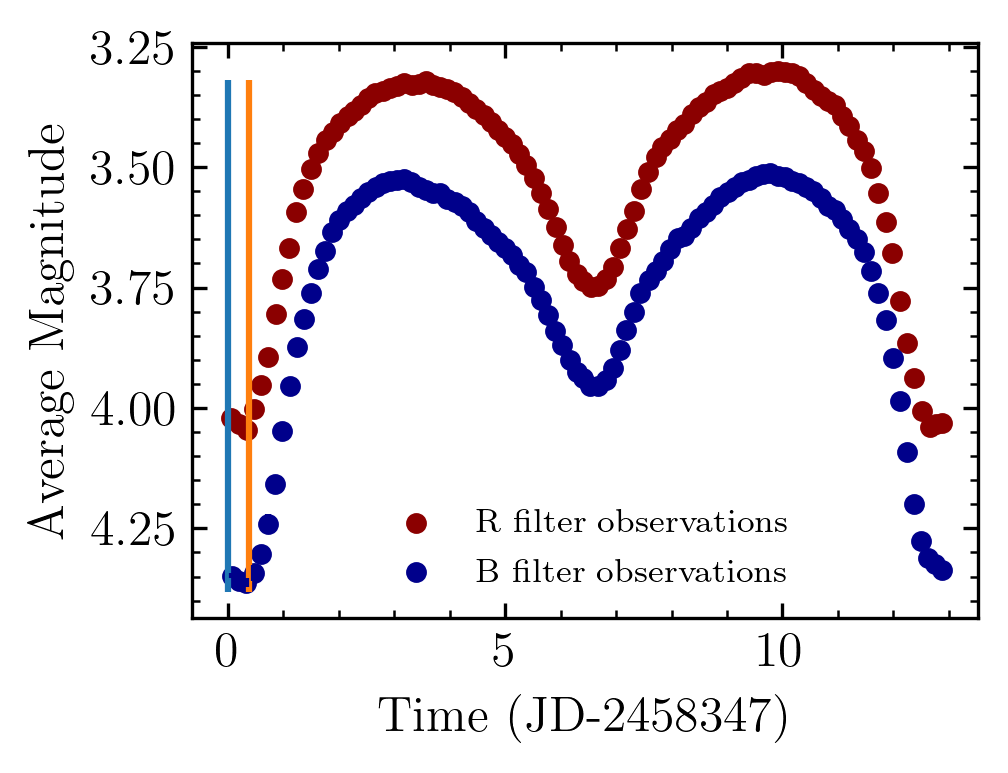

In [66]:
# Beta Lyrae Light Curve
plt.figure()

plt.errorbar(Beta_Lyrae['data_table_R1']['time'], Beta_Lyrae['data_table_R1']['mag'], yerr=Beta_Lyrae['data_table_R1']['mag_error'], ls='none', color='#8b0000')
plt.scatter(Beta_Lyrae['data_table_R1']['time'], Beta_Lyrae['data_table_R1']['mag'], marker='o', color='#8b0000', label = 'R filter observations')


#plt.errorbar(Beta_Lyrae['data_table_R2']['time'], Beta_Lyrae['data_table_R2']['mag'], yerr=Beta_Lyrae['data_table_R2']['mag_error'], ls='none', color='#ff0000')
#plt.scatter(Beta_Lyrae['data_table_R2']['time'], Beta_Lyrae['data_table_R2']['mag'], marker='o', color='#ff0000', label = 'Secondary R filter observations')

plt.errorbar(float(str(Beta_Lyrae["eclipse_time_theoretical"]))-2458347,3.85, yerr=(Beta_Lyrae["eclipse_mag_B"]-Beta_Lyrae["max_light_mag_R1"])/2)
plt.errorbar(Beta_Lyrae["eclipse_time_average"]-2458347,3.85, yerr=(Beta_Lyrae["eclipse_mag_B"]-Beta_Lyrae["max_light_mag_R1"])/2)


plt.errorbar(Beta_Lyrae['data_table_B']['time'], Beta_Lyrae['data_table_B']['mag'], yerr=Beta_Lyrae['data_table_B']['mag_error'], ls='none', color='#00008B')
plt.scatter(Beta_Lyrae['data_table_B']['time'], Beta_Lyrae['data_table_B']['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.legend(loc='best') # display the legend
plt.xlabel('Time (JD-2458347)')
plt.ylabel('Average Magnitude')
plt.gca().invert_yaxis()

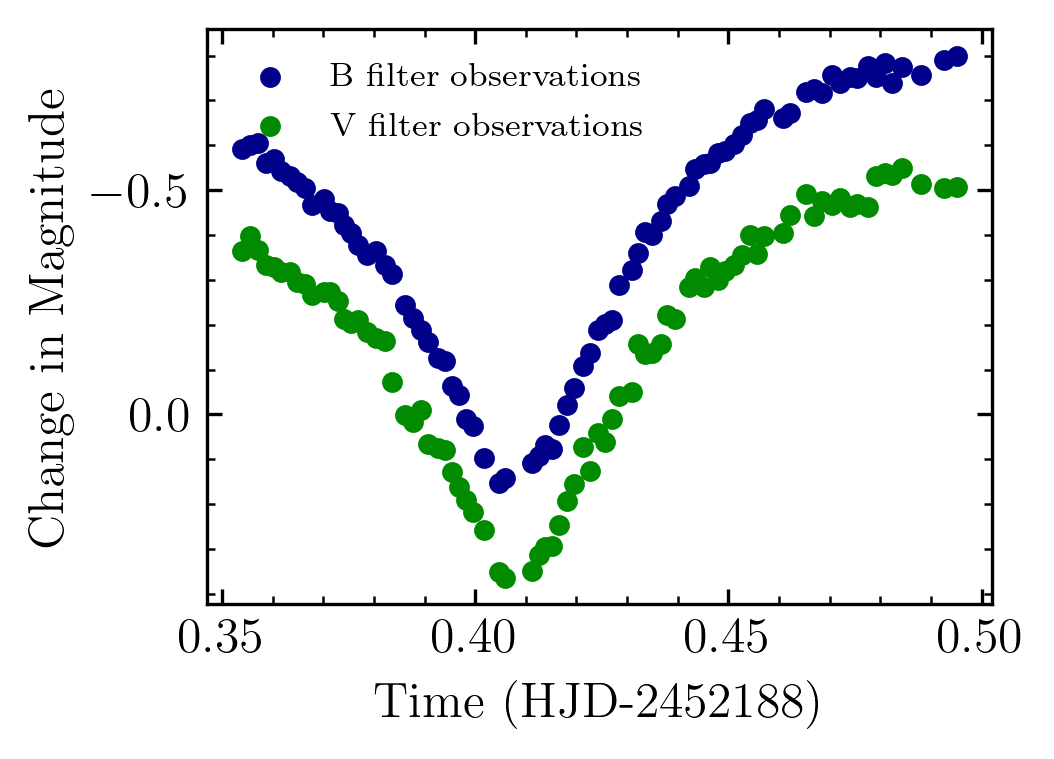

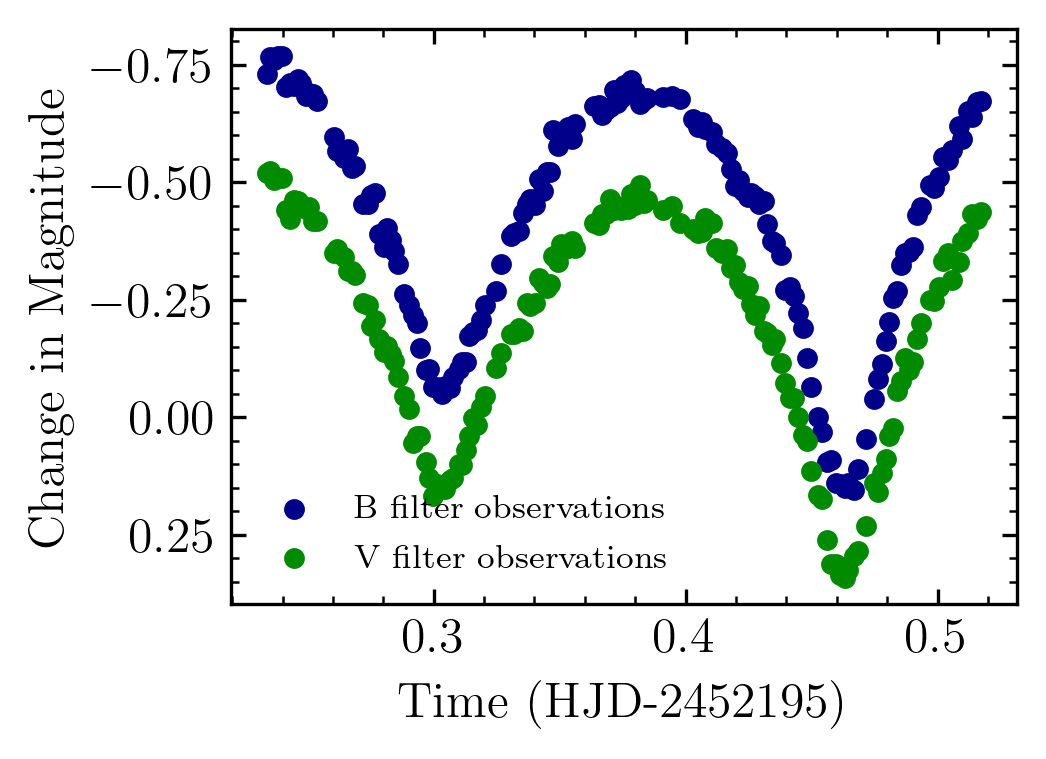

In [3]:
# SW Lac Light Curve 2001
plt.figure()

plt.errorbar(SW_Lac["data_table_B1"]['time'], SW_Lac["data_table_B1"]['mag'], yerr=SW_Lac["data_table_B1"]['mag_error'], ls='none', color='#00008B')
plt.scatter(SW_Lac["data_table_B1"]['time'], SW_Lac["data_table_B1"]['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.errorbar(SW_Lac["data_table_V1"]['time'], SW_Lac["data_table_V1"]['mag'], yerr=SW_Lac["data_table_V1"]['mag_error'], ls='none', color='#008B00')
plt.scatter(SW_Lac["data_table_V1"]['time'], SW_Lac["data_table_V1"]['mag'], marker='o', color='#008B00', label = 'V filter observations')

plt.legend(loc='best') # display the legend
plt.xlabel('Time (HJD-2452188)')
plt.ylabel('Change in Magnitude')
plt.gca().invert_yaxis()


plt.figure()

plt.errorbar(SW_Lac["data_table_B2"]['time'], SW_Lac["data_table_B2"]['mag'], yerr=SW_Lac["data_table_B2"]['mag_error'], ls='none', color='#00008B')
plt.scatter(SW_Lac["data_table_B2"]['time'], SW_Lac["data_table_B2"]['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.errorbar(SW_Lac["data_table_V2"]['time'], SW_Lac["data_table_V2"]['mag'], yerr=SW_Lac["data_table_V2"]['mag_error'], ls='none', color='#008B00')
plt.scatter(SW_Lac["data_table_V2"]['time'], SW_Lac["data_table_V2"]['mag'], marker='o', color='#008B00', label = 'V filter observations')

plt.legend(loc='best') # display the legend
plt.xlabel('Time (HJD-2452195)')
plt.ylabel('Change in Magnitude')
plt.gca().invert_yaxis()

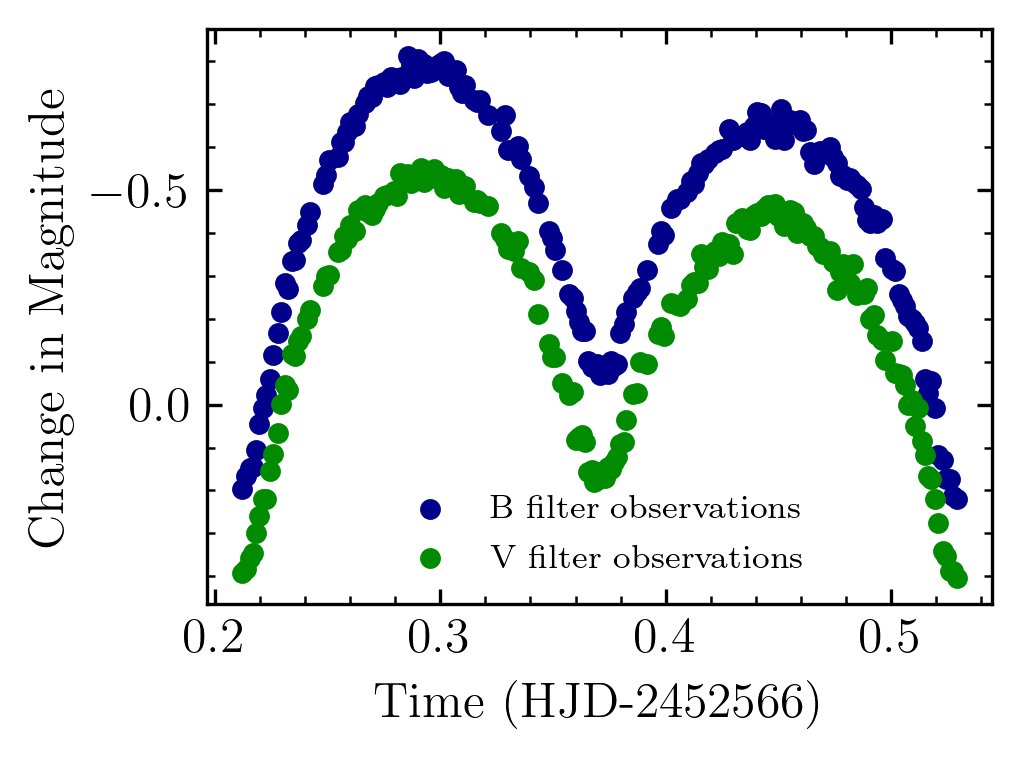

In [4]:
# SW Lac Light Curve 2002
plt.figure()

plt.errorbar(SW_Lac["data_table_B3"]['time'], SW_Lac["data_table_B3"]['mag'], yerr=SW_Lac["data_table_B3"]['mag_error'], ls='none', color='#00008B')
plt.scatter(SW_Lac["data_table_B3"]['time'], SW_Lac["data_table_B3"]['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.errorbar(SW_Lac["data_table_V3"]['time'], SW_Lac["data_table_V3"]['mag'], yerr=SW_Lac["data_table_V3"]['mag_error'], ls='none', color='#008B00')
plt.scatter(SW_Lac["data_table_V3"]['time'], SW_Lac["data_table_V3"]['mag'], marker='o', color='#008B00', label = 'V filter observations')

plt.legend(loc='best') # display the legend
plt.xlabel('Time (HJD-2452566)')
plt.ylabel('Change in Magnitude')
plt.gca().invert_yaxis()

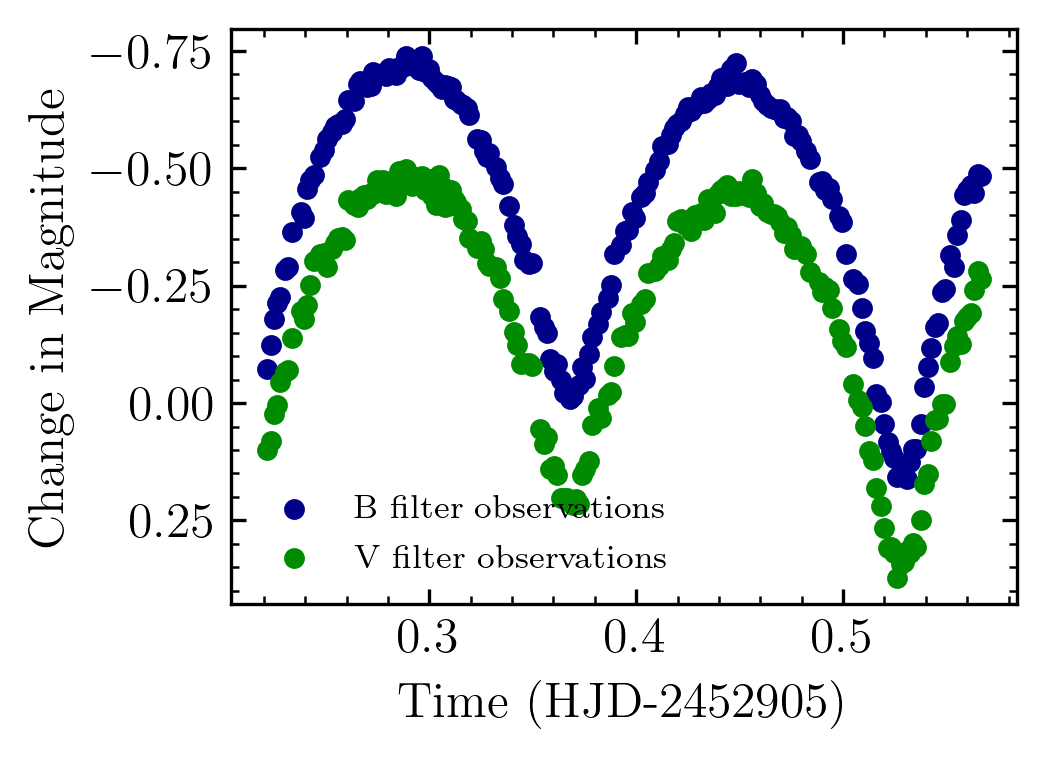

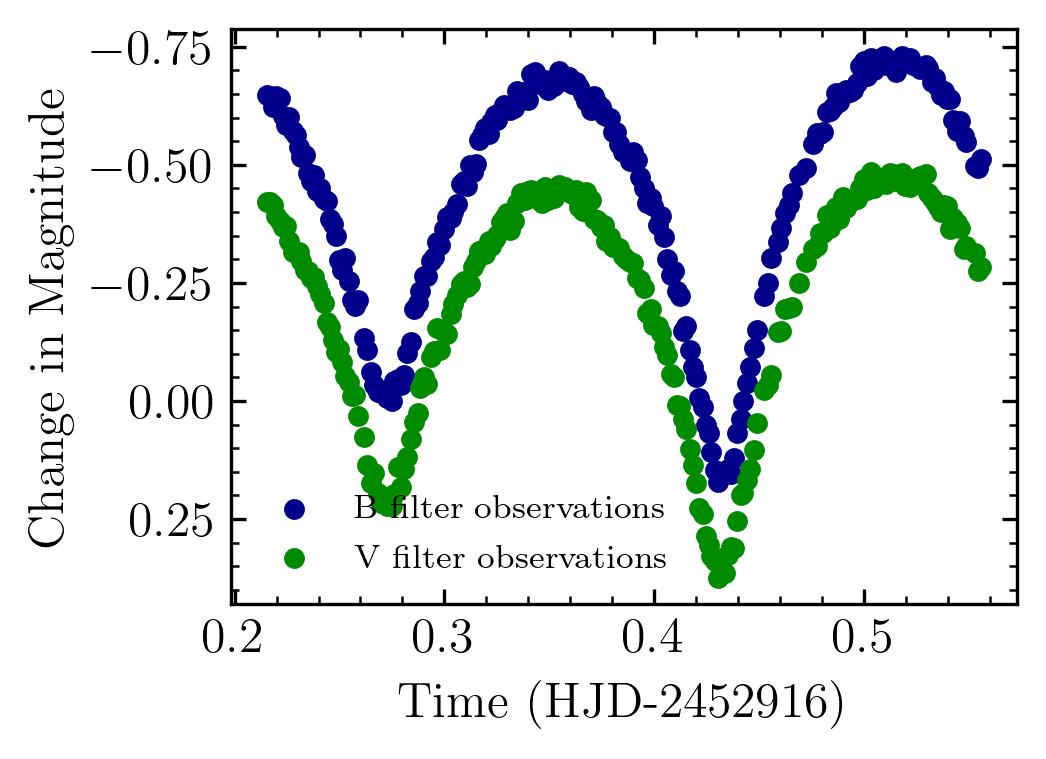

In [5]:
# SW Lac Light Curve 2003

plt.figure()

plt.errorbar(SW_Lac["data_table_B4"]['time'], SW_Lac["data_table_B4"]['mag'], yerr=SW_Lac["data_table_B4"]['mag_error'], ls='none', color='#00008B')
plt.scatter(SW_Lac["data_table_B4"]['time'], SW_Lac["data_table_B4"]['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.errorbar(SW_Lac["data_table_V4"]['time'], SW_Lac["data_table_V4"]['mag'], yerr=SW_Lac["data_table_V4"]['mag_error'], ls='none', color='#008B00')
plt.scatter(SW_Lac["data_table_V4"]['time'], SW_Lac["data_table_V4"]['mag'], marker='o', color='#008B00', label = 'V filter observations')

plt.legend(loc='best') # display the legend
plt.xlabel('Time (HJD-2452905)')
plt.ylabel('Change in Magnitude')
plt.gca().invert_yaxis()


plt.figure()

plt.errorbar(SW_Lac["data_table_B5"]['time'], SW_Lac["data_table_B5"]['mag'], yerr=SW_Lac["data_table_B5"]['mag_error'], ls='none', color='#00008B')
plt.scatter(SW_Lac["data_table_B5"]['time'], SW_Lac["data_table_B5"]['mag'], marker='o', color='#00008B', label = 'B filter observations')


plt.errorbar(SW_Lac["data_table_V5"]['time'], SW_Lac["data_table_V5"]['mag'], yerr=SW_Lac["data_table_V5"]['mag_error'], ls='none', color='#008B00')
plt.scatter(SW_Lac["data_table_V5"]['time'], SW_Lac["data_table_V5"]['mag'], marker='o', color='#008B00', label = 'V filter observations')

plt.legend(loc='best') # display the legend
plt.xlabel('Time (HJD-2452916)')
plt.ylabel('Change in Magnitude')
plt.gca().invert_yaxis()

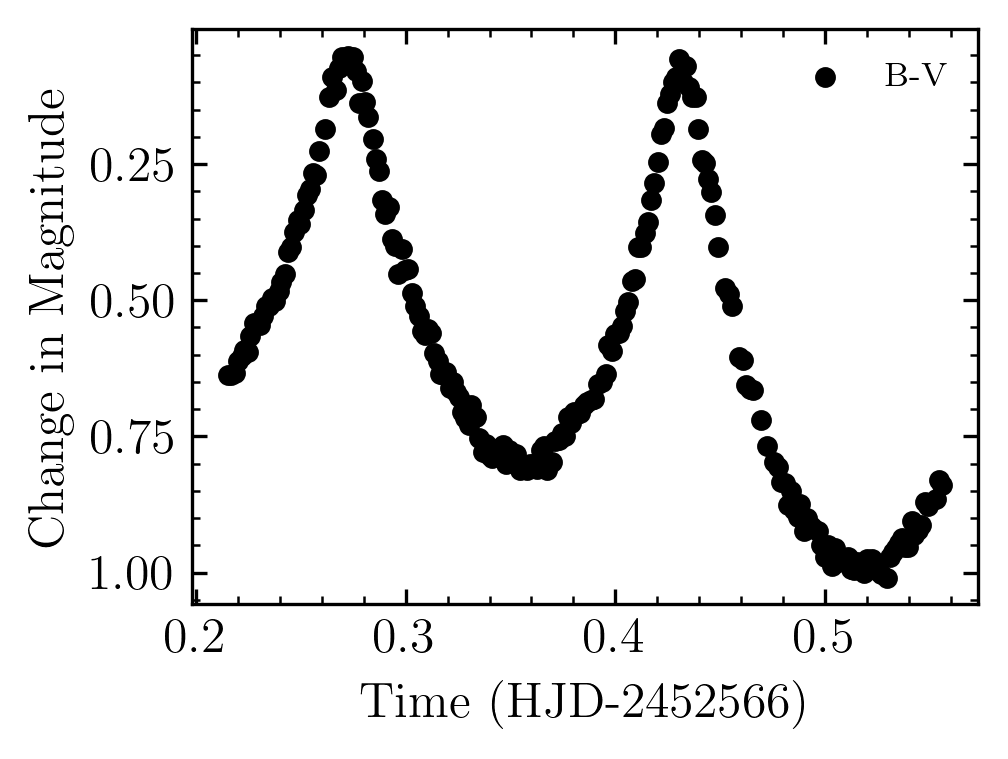

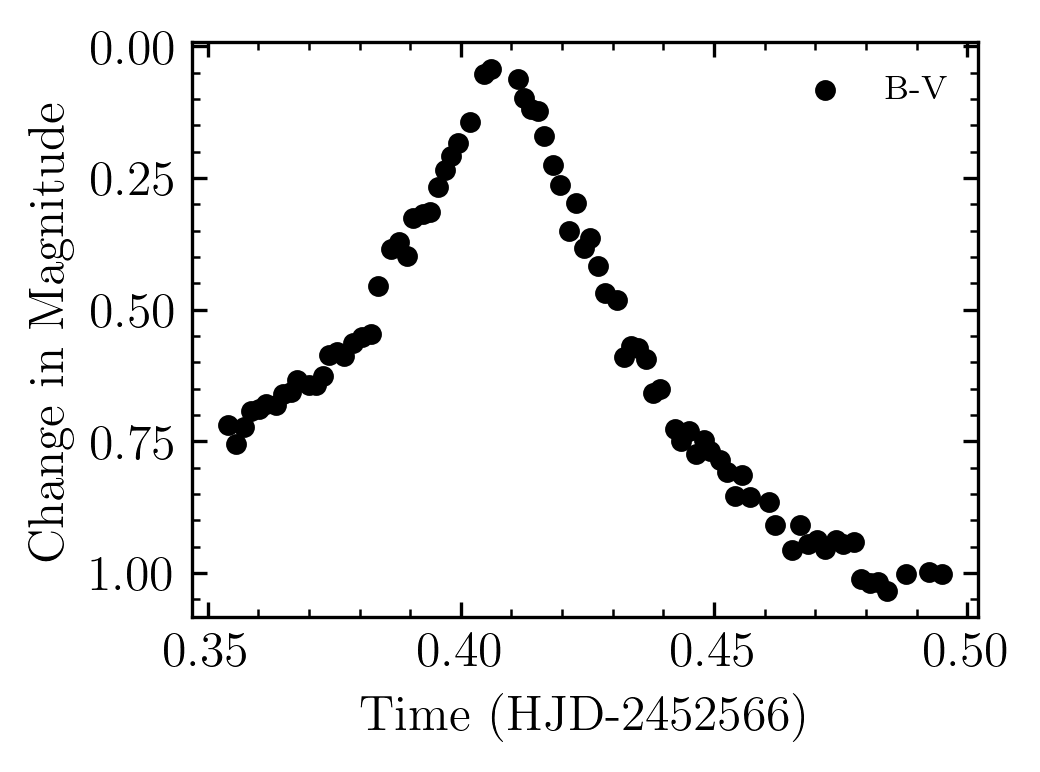

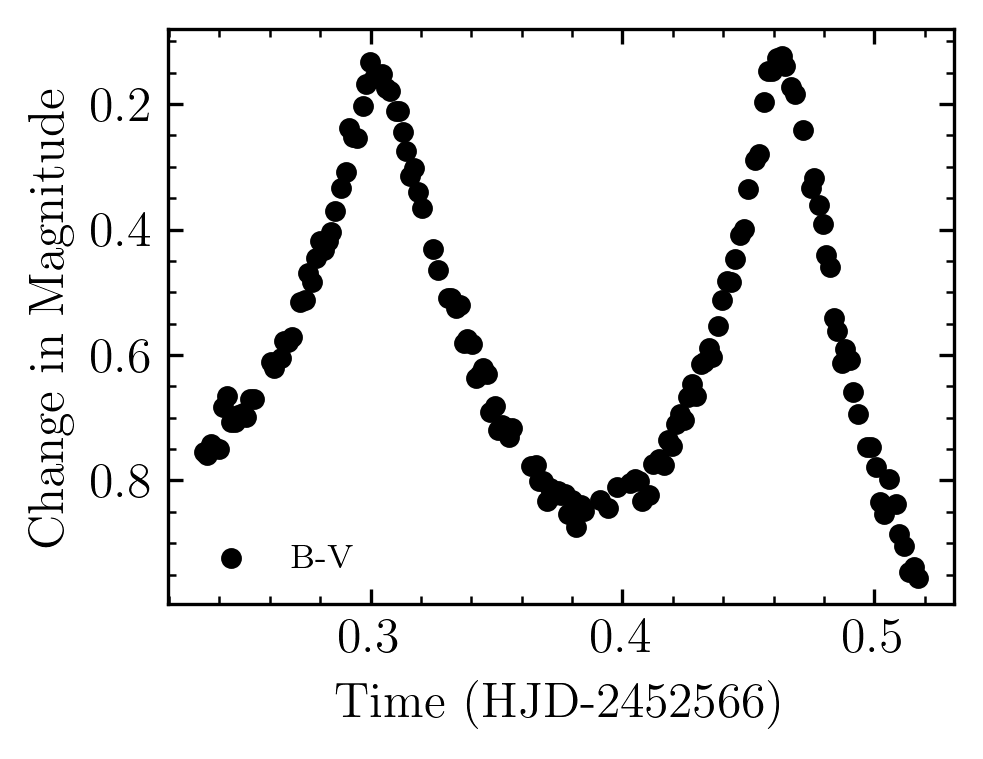

In [67]:
bv(1)
bv(2)

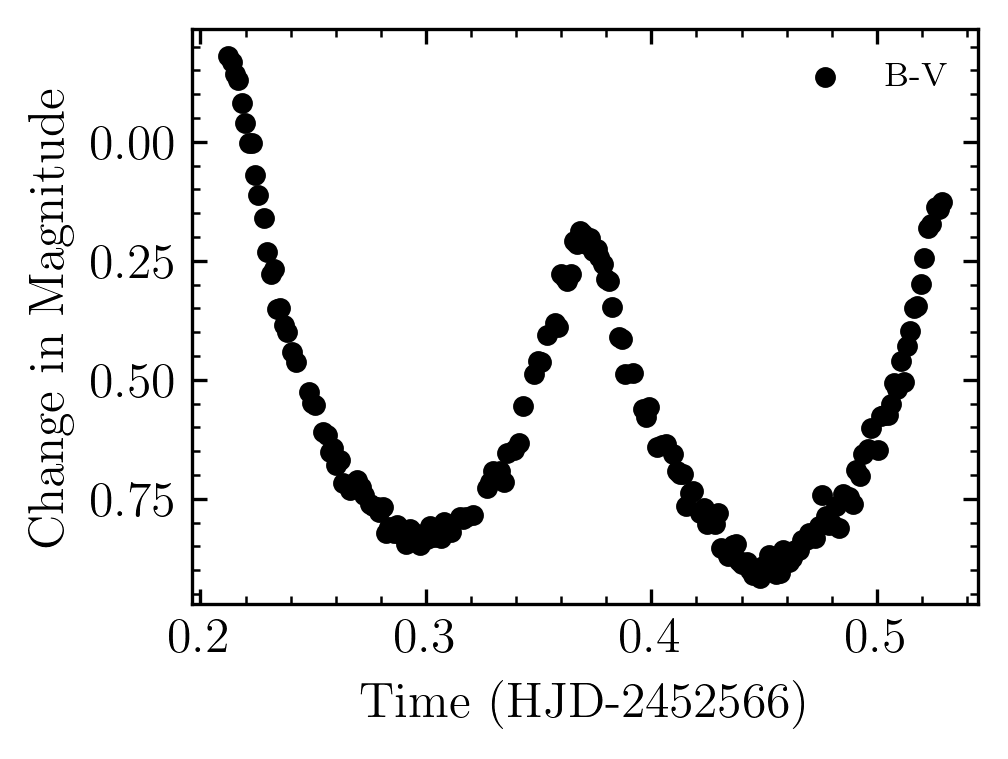

In [68]:
bv(3)

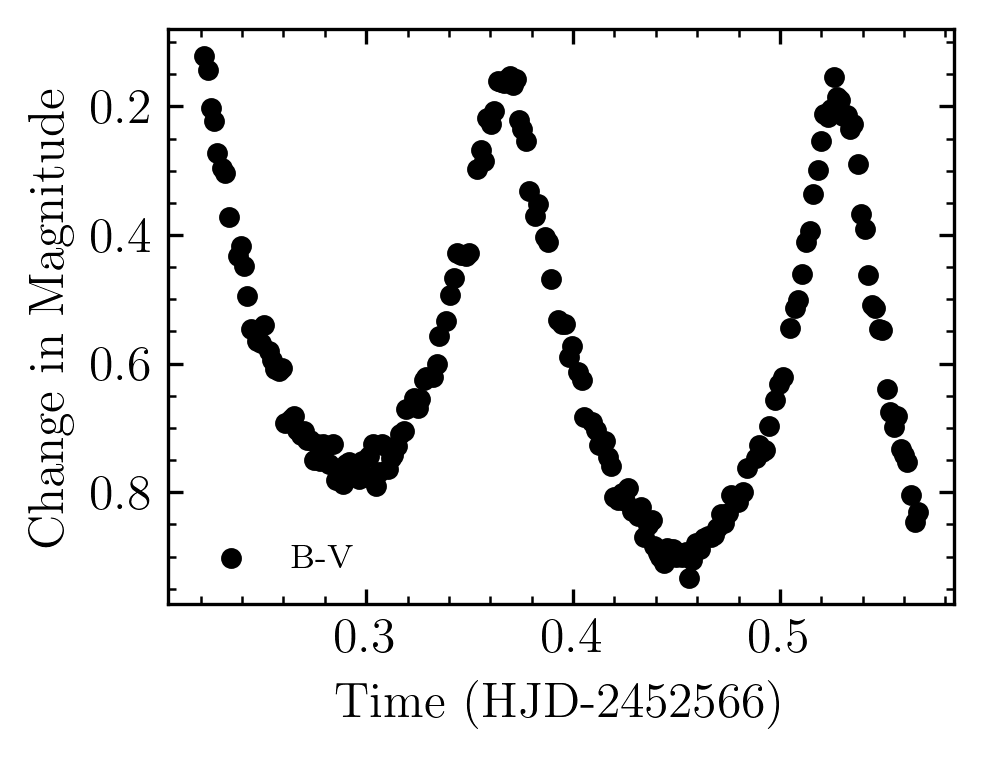

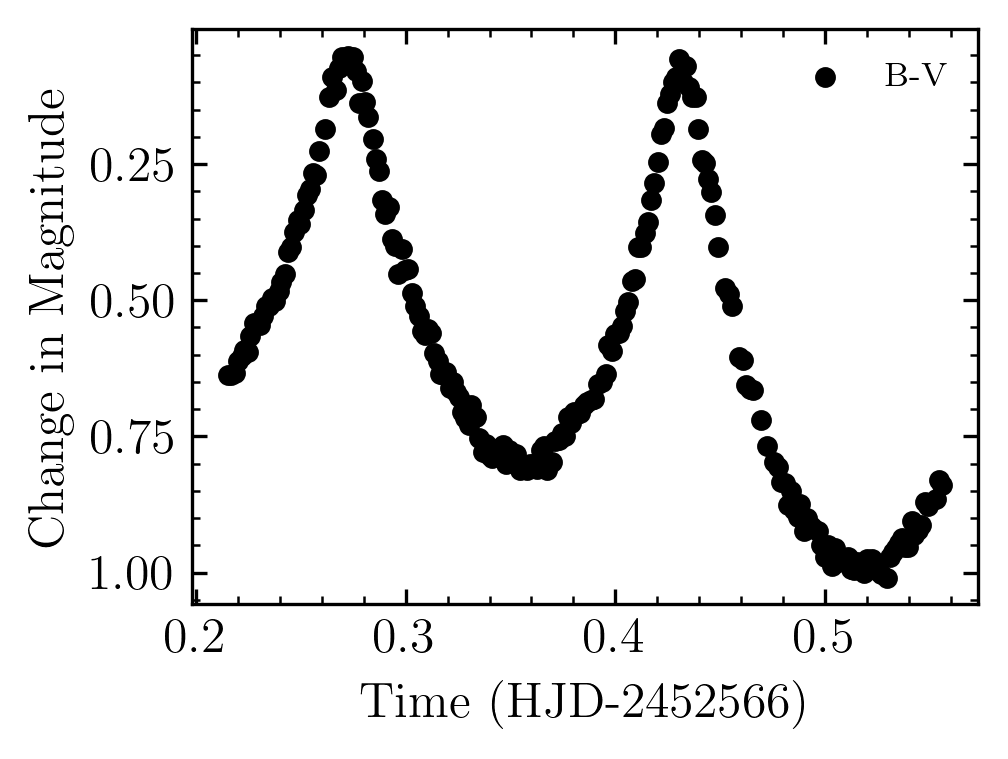

In [69]:
bv(4)
bv(5)